<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/nlp/NLP-assignment-P03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/nlp/NLP-assignment-P03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laporan Ilmiah P03
## Text Preprocessing dan REST API Flask untuk NLP

**Materi:** Advanced NLP  
**Lingkungan:** Google Colab  


## ABSTRAK

Penelitian ini membahas penerapan text preprocessing pada data bahasa alami menggunakan NLTK dan Stanza. Tahapan yang dikaji meliputi normalisasi, penghapusan tanda baca, tokenisasi, stopword removal, stemming, lemmatisasi, part-of-speech tagging, dependency parsing, dan named entity recognition. Hasil preprocessing diintegrasikan ke dalam REST API menggunakan Flask dan diuji menggunakan Flask test client di Google Colab. Pengujian menunjukkan bahwa pipeline dapat menerima teks melalui endpoint HTTP dan mengembalikan hasil pemrosesan dalam format JSON.

**Kata kunci:** NLP, text preprocessing, NLTK, Stanza, TF-IDF, Flask.


## BAB 1 — PENDAHULUAN

### 1.1 Latar Belakang

Data teks bersifat tidak terstruktur dan memiliki variasi ejaan, kapitalisasi, tanda baca, serta bentuk kata. Kondisi tersebut dapat menimbulkan noise dan ketidakkonsistenan apabila teks langsung digunakan dalam analisis atau pembelajaran mesin. Text preprocessing diperlukan untuk mengubah teks mentah menjadi representasi yang lebih teratur.

Selain menghasilkan analisis di dalam notebook, pipeline preprocessing dapat disediakan sebagai layanan yang dapat dipanggil oleh aplikasi lain. Flask dipilih karena ringan dan menyediakan mekanisme routing untuk membangun REST API.

### 1.2 Rumusan Masalah

1. Bagaimana menerapkan tahapan preprocessing teks menggunakan NLTK dan Stanza?
2. Bagaimana menyediakan hasil preprocessing melalui API Flask?
3. Apakah endpoint API dapat diuji secara terprogram di Google Colab?

### 1.3 Tujuan

Penelitian ini bertujuan membangun pipeline preprocessing NLP, membandingkan fungsi NLTK dan Stanza, mengintegrasikan pipeline ke Flask, serta menguji validitas respons API.

### 1.4 Manfaat

Hasil penelitian dapat menjadi contoh implementasi preprocessing yang reproducible dan dasar pengembangan layanan NLP untuk aplikasi klasifikasi, pencarian informasi, atau analisis teks.


## BAB 2 — TINJAUAN PUSTAKA

### 2.1 Natural Language Processing

Natural Language Processing (NLP) adalah bidang ilmu komputer dan kecerdasan buatan yang mempelajari interaksi antara komputer dan bahasa manusia. NLP mencakup tugas tokenisasi, klasifikasi teks, information retrieval, machine translation, question answering, dan information extraction [1], [5].

### 2.2 Text Preprocessing

Text preprocessing adalah proses transformasi teks mentah sebelum digunakan oleh algoritma. Tahap umum meliputi normalisasi huruf, penghapusan tanda baca, tokenisasi, penghapusan stopword, stemming, dan lemmatisasi. Tidak semua tahap wajib digunakan; pemilihannya bergantung pada bahasa, domain, dan tujuan model.

### 2.3 Normalisasi dan Tokenisasi

Normalisasi mengurangi variasi permukaan, misalnya mengubah seluruh huruf menjadi lowercase. Tokenisasi memecah teks menjadi unit yang lebih kecil berupa kata atau token. Tokenisasi harus mempertimbangkan tanda baca, kontraksi, angka, URL, dan karakter khusus.

### 2.4 Stopword Removal

Stopword adalah kata yang sering muncul dan biasanya memiliki informasi leksikal rendah, seperti “is”, “the”, dan “of” dalam bahasa Inggris. Penghapusan stopword dapat mengurangi dimensi fitur, tetapi tidak selalu tepat untuk analisis sintaksis, terjemahan mesin, atau analisis sentimen.

### 2.5 Stemming

Stemming mengurangi kata berimbuhan ke bentuk dasar dengan aturan pemotongan. Metode ini cepat, tetapi hasilnya dapat berupa bentuk yang tidak terdapat dalam kamus. Porter Stemmer merupakan salah satu stemmer populer untuk bahasa Inggris. Untuk bahasa Indonesia dapat digunakan stemmer khusus seperti Sastrawi.

### 2.6 Lemmatisasi

Lemmatisasi mengubah kata ke lemma berdasarkan informasi morfologi dan kamus. Dibandingkan stemming, lemmatisasi cenderung menghasilkan bentuk yang lebih bermakna, tetapi membutuhkan resource bahasa dan proses yang lebih kompleks.

### 2.7 Part-of-Speech, Dependency Parsing, dan NER

Part-of-speech (POS) tagging memberikan label gramatikal seperti noun, verb, dan adjective. Dependency parsing memetakan hubungan sintaksis antar-token. Named Entity Recognition (NER) mengenali entitas seperti nama orang, organisasi, lokasi, dan tanggal. Ketiga anotasi ini membantu memahami struktur dan informasi penting dalam teks.

### 2.8 NLTK

NLTK adalah toolkit Python yang modular untuk pembelajaran dan eksperimen NLP. NLTK menyediakan tokenizer, corpus stopword, stemmer, lemmatizer, dan POS tagger. Keunggulannya adalah API yang mudah dipahami dan cocok untuk preprocessing klasik [1].

### 2.9 Stanza

Stanza adalah toolkit NLP berbasis neural yang menyediakan pipeline multilingual. Pipeline Stanza dapat menghasilkan token, lemma, POS, dependency relation, dan entitas bernama. Model bahasa harus diunduh terlebih dahulu dan hasilnya bergantung pada resource bahasa yang digunakan [2].

### 2.10 TF-IDF

Term Frequency–Inverse Document Frequency (TF-IDF) memberikan bobot pada kata berdasarkan frekuensi kata dalam dokumen dan kelangkaannya pada kumpulan dokumen. Secara umum, bobot dirumuskan sebagai:

`TF-IDF(t,d) = TF(t,d) × IDF(t)`

Kata yang sering muncul pada dokumen tertentu tetapi jarang muncul pada dokumen lain memperoleh bobot lebih besar [4], [5].

### 2.11 Flask dan REST API

Flask adalah microframework Python untuk aplikasi web [3]. REST API menyediakan fungsi aplikasi melalui endpoint HTTP. Pada penelitian ini, `GET /` digunakan untuk informasi layanan dan `POST /process` digunakan untuk menerima JSON berisi teks dan mengembalikan hasil preprocessing.

### 2.12 Google Colab dan Reproducibility

Google Colab menyediakan runtime Python berbasis cloud yang sesuai untuk eksperimen notebook. Karena runtime bersifat sementara, library dan resource harus dipasang atau diunduh kembali ketika sesi baru dimulai. Pengujian menggunakan `app.test_client()` memungkinkan endpoint diuji tanpa deployment publik atau tunnel.


## BAB 3 — METODOLOGI PENELITIAN

### 3.1 Desain Penelitian

Penelitian dilakukan secara eksperimental melalui tahapan instalasi resource, preprocessing teks dengan NLTK, anotasi linguistik dengan Stanza, integrasi Flask, dan pengujian respons API.

### 3.2 Data dan Skenario Uji

Data uji berupa kalimat bahasa Inggris yang dipilih agar dapat diproses oleh resource standar NLTK. Skenario pengujian mencakup akses endpoint informasi, input teks valid, input kosong, input berisi spasi, JSON tanpa field `text`, request bukan JSON, serta teks yang mengandung angka dan tanda baca.

### 3.3 Alur Penelitian

Alur penelitian adalah: (1) memasang library, (2) mengunduh resource bahasa, (3) memproses teks, (4) menghitung TF-IDF, (5) menyediakan hasil melalui Flask, dan (6) memeriksa status serta isi respons endpoint.

### 3.4 Indikator Keberhasilan

Implementasi dinyatakan berhasil apabila preprocessing menghasilkan token dan fitur, `GET /` menghasilkan status 200, `POST /process` dengan input valid menghasilkan status 200 dan JSON, sedangkan input tidak valid menghasilkan status 400.

### 3.5 Lingkungan dan Spesifikasi Komputasi

Eksperimen dijalankan pada Google Colab menggunakan runtime Python berbasis CPU. Runtime CPU dipilih karena tahapan normalisasi, tokenisasi, stopword removal, stemming, lemmatisasi, POS tagging, pembentukan TF-IDF, dan pengujian Flask pada data berukuran kecil tidak memerlukan akselerasi GPU. GPU NVIDIA T4 bersifat opsional dan tidak memberikan peningkatan yang signifikan untuk skenario pengujian ini.

Kebutuhan komputasi utama berasal dari pengunduhan dan pemuatan model Stanza. Proses tersebut dapat memerlukan waktu lebih lama dibandingkan NLTK, TF-IDF, dan Flask, tetapi tetap dapat dijalankan menggunakan CPU. Kebutuhan RAM dan penyimpanan mengikuti model bahasa yang dimuat serta jumlah dokumen yang diproses. Eksperimen ini menggunakan satu kalimat uji sehingga runtime standar Google Colab sudah mencukupi.

Google Colab menyediakan lingkungan yang bersifat sementara. Library yang dipasang, resource NLTK, model Stanza, variabel, dan output dapat hilang ketika runtime di-reset atau sesi berakhir. Oleh karena itu, cell instalasi dan pengunduhan resource ditempatkan pada awal tahap implementasi agar lingkungan dapat dibangun kembali secara konsisten.

Untuk mendukung reproducibility, notebook mencatat platform sistem operasi, versi Python, jumlah CPU logis, kapasitas RAM, ketersediaan GPU NVIDIA, serta versi NLTK, Stanza, scikit-learn, dan Flask. Nilai spesifikasi tidak ditulis secara permanen karena alokasi resource Google Colab dapat berbeda pada setiap sesi. Angka aktual diperoleh dari output script ketika notebook dijalankan.

Prosedur reproduksi dilakukan dengan memilih runtime CPU, kemudian menjalankan seluruh cell secara berurutan dari atas ke bawah. Setelah instalasi selesai, resource NLTK dan model Stanza dimuat, pipeline preprocessing dijalankan, endpoint Flask diuji menggunakan test client, dan hasil pengujian digunakan untuk membentuk ringkasan serta kesimpulan otomatis.


## BAB 4 — IMPLEMENTASI, HASIL, DAN PEMBAHASAN

Bab ini menyajikan implementasi secara naratif. Setiap tahap dijelaskan, dijalankan, dan hasilnya dianalisis. Jalankan cell secara berurutan dari awal agar resource dan fungsi tersedia.

### 4.1 Persiapan Lingkungan

Library berikut digunakan untuk preprocessing, anotasi linguistik, pembentukan fitur, dan API Flask.

In [1]:
%pip install -q nltk stanza scikit-learn flask

import string
import nltk

resources = [
    ('tokenizers/punkt', 'punkt'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('corpora/stopwords', 'stopwords'),
    ('corpora/wordnet', 'wordnet'),
    ('corpora/omw-1.4', 'omw-1.4'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
]
for path, package in resources:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(package, quiet=True)
print('Resource NLTK siap digunakan.')

# Mencatat spesifikasi runtime untuk reproducibility.
import os
import platform
import shutil
from importlib.metadata import version

ram_gb = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024 ** 3)
gpu_available = shutil.which('nvidia-smi') is not None

print('\nSPESIFIKASI RUNTIME')
print('Platform       :', platform.platform())
print('Python         :', platform.python_version())
print('CPU logical    :', os.cpu_count())
print(f'RAM total      : {ram_gb:.2f} GB')
print('GPU NVIDIA     :', 'Tersedia' if gpu_available else 'Tidak tersedia / tidak diperlukan')
print('NLTK           :', version('nltk'))
print('Stanza         :', version('stanza'))
print('scikit-learn   :', version('scikit-learn'))
print('Flask          :', version('flask'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 19.3 MB/s eta 0:00:00
Resource NLTK siap digunakan.

SPESIFIKASI RUNTIME
Platform       : Linux-6.6.122+-x86_64-with-glibc2.39
Python         : 3.13.15
CPU logical    : 2
RAM total      : 12.67 GB
GPU NVIDIA     : Tidak tersedia / tidak diperlukan
NLTK           : 3.9.1
Stanza         : 1.14.0
scikit-learn   : 1.6.1
Flask          : 3.1.3


### 4.2 Preprocessing dengan NLTK

Pada tahap ini teks dinormalisasi, dibersihkan, dipecah menjadi token, disaring dari stopword, kemudian diproses dengan stemming, lemmatisasi, dan POS tagging.

In [2]:
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    normalized = text.lower()
    without_punctuation = normalized.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(without_punctuation)
    stop_words = set(stopwords.words('english'))
    filtered = [t for t in tokens if t.isalnum() and t not in stop_words]
    stemmed = [PorterStemmer().stem(t) for t in filtered]
    lemmatized = [WordNetLemmatizer().lemmatize(t) for t in filtered]
    tagged = pos_tag(filtered)
    return {
        'original_text': text, 'normalized_text': normalized,
        'without_punctuation': without_punctuation, 'tokens': tokens,
        'filtered_tokens': filtered, 'stemmed_tokens': stemmed,
        'lemmatized_tokens': lemmatized, 'pos_tagged_tokens': tagged,
    }

text = 'Natural Language Processing is a field of artificial intelligence.'
nltk_result = preprocess_text(text)
for key, value in nltk_result.items():
    print(f'{key}: {value}')

original_text: Natural Language Processing is a field of artificial intelligence.
normalized_text: natural language processing is a field of artificial intelligence.
without_punctuation: natural language processing is a field of artificial intelligence
tokens: ['natural', 'language', 'processing', 'is', 'a', 'field', 'of', 'artificial', 'intelligence']
filtered_tokens: ['natural', 'language', 'processing', 'field', 'artificial', 'intelligence']
stemmed_tokens: ['natur', 'languag', 'process', 'field', 'artifici', 'intellig']
lemmatized_tokens: ['natural', 'language', 'processing', 'field', 'artificial', 'intelligence']
pos_tagged_tokens: [('natural', 'JJ'), ('language', 'NN'), ('processing', 'NN'), ('field', 'NN'), ('artificial', 'JJ'), ('intelligence', 'NN')]


Hasil di atas memperlihatkan perubahan teks pada setiap tahap. Lowercasing menyamakan kapitalisasi, punctuation removal menghapus titik, dan stopword removal mengurangi kata umum. Stemming dapat menghasilkan bentuk terpotong, sedangkan lemmatisasi cenderung mempertahankan bentuk kata yang lebih bermakna.

,Tahap,Hasil
0,Original,Natural Language Processing is a field of arti...
1,Normalized,natural language processing is a field of arti...
2,Without Punctuation,natural language processing is a field of arti...
3,Tokens,"natural, language, processing, is, a, field, o..."
4,Filtered Tokens,"natural, language, processing, field, artifici..."
5,Stemmed Tokens,"natur, languag, process, field, artifici, inte..."
6,Lemmatized Tokens,"natural, language, processing, field, artifici..."


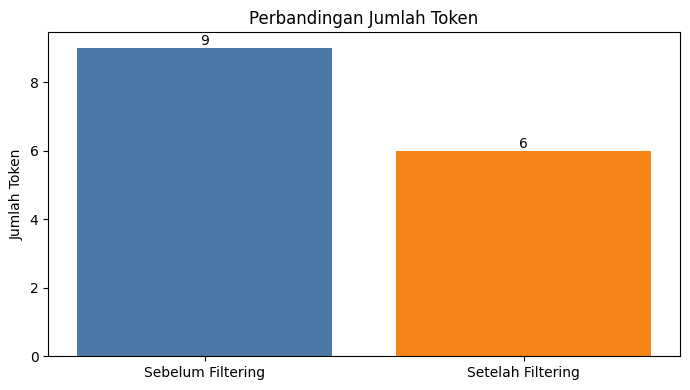

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

preprocessing_table = pd.DataFrame({
    "Tahap": [
        "Original",
        "Normalized",
        "Without Punctuation",
        "Tokens",
        "Filtered Tokens",
        "Stemmed Tokens",
        "Lemmatized Tokens",
    ],
    "Hasil": [
        nltk_result["original_text"],
        nltk_result["normalized_text"],
        nltk_result["without_punctuation"],
        ", ".join(nltk_result["tokens"]),
        ", ".join(nltk_result["filtered_tokens"]),
        ", ".join(nltk_result["stemmed_tokens"]),
        ", ".join(nltk_result["lemmatized_tokens"]),
    ],
})

display(preprocessing_table)

token_counts = {
    "Sebelum Filtering": len(nltk_result["tokens"]),
    "Setelah Filtering": len(nltk_result["filtered_tokens"]),
}

plt.figure(figsize=(7, 4))
bars = plt.bar(
    token_counts.keys(),
    token_counts.values(),
    color=["#4C78A8", "#F58518"],
)

plt.title("Perbandingan Jumlah Token")
plt.ylabel("Jumlah Token")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 4.3 Pembentukan Fitur TF-IDF

TF-IDF digunakan untuk mengubah token hasil lemmatisasi menjadi bobot numerik.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([' '.join(nltk_result['lemmatized_tokens'])])
tfidf_result = dict(zip(vectorizer.get_feature_names_out(), tfidf_matrix.toarray()[0].round(6)))
print(tfidf_result)

{'artificial': np.float64(0.408248), 'field': np.float64(0.408248), 'intelligence': np.float64(0.408248), 'language': np.float64(0.408248), 'natural': np.float64(0.408248), 'processing': np.float64(0.408248)}


TF-IDF menghasilkan representasi numerik yang dapat digunakan sebagai fitur oleh algoritma machine learning. Pada satu dokumen, bobot terutama menunjukkan kontribusi relatif setiap kata setelah preprocessing.

,Kata,Bobot TF-IDF
0,artificial,0.408248
1,field,0.408248
2,intelligence,0.408248
3,language,0.408248
4,natural,0.408248
5,processing,0.408248


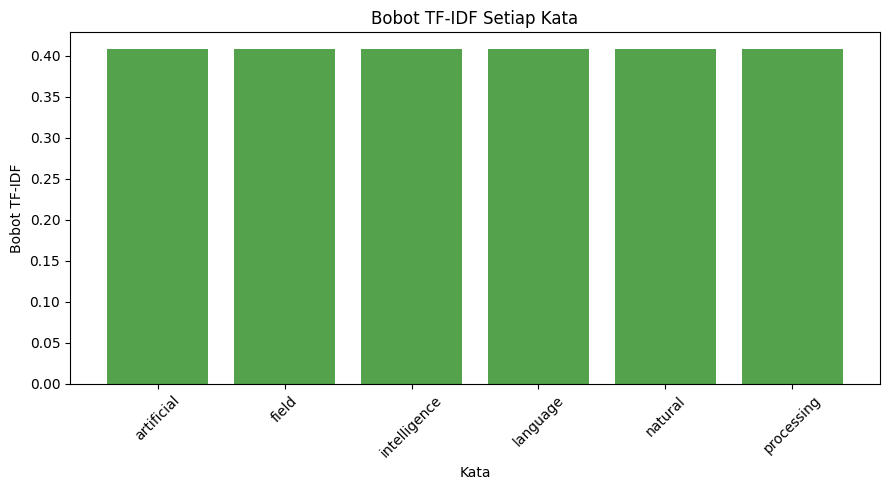

In [13]:
tfidf_table = pd.DataFrame({
    "Kata": list(tfidf_result.keys()),
    "Bobot TF-IDF": list(tfidf_result.values()),
}).sort_values("Bobot TF-IDF", ascending=False)

display(tfidf_table)

plt.figure(figsize=(9, 5))
plt.bar(
    tfidf_table["Kata"],
    tfidf_table["Bobot TF-IDF"],
    color="#54A24B",
)

plt.title("Bobot TF-IDF Setiap Kata")
plt.xlabel("Kata")
plt.ylabel("Bobot TF-IDF")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Anotasi Linguistik dengan Stanza

Stanza digunakan untuk memperoleh lemma, POS, dependency relation, dan NER. Model bahasa Inggris diunduh pada runtime Colab.

In [4]:
import stanza
print('Mengunduh atau memverifikasi model Stanza bahasa Inggris...')
stanza.download('en', verbose=False)
print('Model Stanza siap digunakan.')
nlp_en = stanza.Pipeline('en', processors='tokenize,mwt,pos,lemma,depparse,ner', verbose=False)
doc = nlp_en('Sajarwo Anggai teaches Advanced NLP at Pamulang University.')
for sentence in doc.sentences:
    print('Tokens:', [(w.text, w.lemma, w.upos, w.deprel) for w in sentence.words])
    print('NER:', [(e.text, e.type) for e in sentence.ents])

Mengunduh atau memverifikasi model Stanza bahasa Inggris...


models/default.zip: reconstructing file:   0%|          |  0.00B /  525MB            

models/default.zip: downloading bytes:           |  0.00B            

Model Stanza siap digunakan.
Tokens: [('Sajarwo', 'Sajarwo', 'PROPN', 'nsubj'), ('Anggai', 'Anggai', 'PROPN', 'flat'), ('teaches', 'teach', 'VERB', 'root'), ('Advanced', 'Advanced', 'ADJ', 'amod'), ('NLP', 'NLP', 'PROPN', 'obj'), ('at', 'at', 'ADP', 'case'), ('Pamulang', 'Pamulang', 'PROPN', 'compound'), ('University', 'University', 'PROPN', 'obl'), ('.', '.', 'PUNCT', 'punct')]
NER: [('Sajarwo Anggai', 'PERSON'), ('Advanced NLP', 'ORG'), ('Pamulang University', 'ORG')]


Stanza melengkapi preprocessing dasar dengan informasi linguistik. POS menunjukkan fungsi gramatikal, dependency menunjukkan hubungan sintaksis, dan NER membantu menemukan entitas penting.

In [14]:
stanza_rows = []
ner_rows = []

for sentence_id, sentence in enumerate(doc.sentences, start=1):
    for word in sentence.words:
        stanza_rows.append({
            "Kalimat": sentence_id,
            "Token": word.text,
            "Lemma": word.lemma,
            "POS": word.upos,
            "Head": word.head,
            "Dependency": word.deprel,
        })

    for entity in sentence.ents:
        ner_rows.append({
            "Kalimat": sentence_id,
            "Entitas": entity.text,
            "Tipe": entity.type,
        })

stanza_table = pd.DataFrame(stanza_rows)
ner_table = pd.DataFrame(ner_rows)

print("Hasil POS Tagging dan Dependency Parsing")
display(stanza_table)

print("Hasil Named Entity Recognition")
if ner_table.empty:
    print("Tidak ada entitas yang terdeteksi.")
else:
    display(ner_table)

Hasil POS Tagging dan Dependency Parsing


,Kalimat,Token,Lemma,POS,Head,Dependency
0,1,Sajarwo,Sajarwo,PROPN,3,nsubj
1,1,Anggai,Anggai,PROPN,1,flat
2,1,teaches,teach,VERB,0,root
3,1,Advanced,Advanced,ADJ,5,amod
4,1,NLP,NLP,PROPN,3,obj
5,1,at,at,ADP,8,case
6,1,Pamulang,Pamulang,PROPN,8,compound
7,1,University,University,PROPN,3,obl
8,1,.,.,PUNCT,3,punct


Hasil Named Entity Recognition


,Kalimat,Entitas,Tipe
0,1,Sajarwo Anggai,PERSON
1,1,Advanced NLP,ORG
2,1,Pamulang University,ORG


### 4.5 Implementasi REST API Flask

Pipeline kemudian dibungkus ke dalam Flask. Endpoint menerima JSON dengan field `text`, memvalidasi input, menjalankan preprocessing, dan mengembalikan JSON.

In [5]:
from flask import Flask, jsonify, request

app = Flask(__name__)

def api_preprocess(text):
    result = preprocess_text(text)
    lemmas = result['lemmatized_tokens']
    if lemmas:
        # Satu vectorizer digunakan agar matriks dan nama fitur konsisten.
        v = TfidfVectorizer()
        matrix = v.fit_transform([' '.join(lemmas)])
        result['tfidf'] = dict(zip(v.get_feature_names_out(), matrix.toarray()[0].round(6).tolist()))
    else:
        result['tfidf'] = {}
    return result

@app.get('/')
def home():
    return jsonify({'application': 'Text Preprocessing API', 'endpoint': 'POST /process'})

@app.post('/process')
def process():
    data = request.get_json(silent=True) or {}
    text = data.get('text')
    if not isinstance(text, str) or not text.strip():
        return jsonify({'error': "Field 'text' wajib berupa teks dan tidak kosong."}), 400
    return jsonify(api_preprocess(text))

print('Flask app siap diuji.')

Flask app siap diuji.


### 4.6 Pengujian Endpoint di Google Colab

Pengujian menggunakan Flask test client. Pendekatan ini menjalankan request secara lokal di runtime Colab sehingga tidak memerlukan server publik. Pengujian mencakup respons sukses, validasi beberapa bentuk input tidak valid, dan pemrosesan teks dengan angka serta tanda baca. Setelah seluruh cell dijalankan, simpan notebook agar output pengujian tercatat sebagai bukti eksperimen.

In [6]:
client = app.test_client()

home_response = client.get('/')
valid_response = client.post('/process', json={'text': 'Natural Language Processing is useful.'})
empty_response = client.post('/process', json={'text': ''})
whitespace_response = client.post('/process', json={'text': '   '})
missing_field_response = client.post('/process', json={'message': 'tanpa field text'})
non_json_response = client.post('/process', data='teks biasa', content_type='text/plain')
punctuation_response = client.post('/process', json={'text': 'NLP 2026: useful, fast, and practical!'})

print('GET /:', home_response.status_code, home_response.get_json())
print('POST /process:', valid_response.status_code)
print(valid_response.get_json())
print('Input kosong:', empty_response.status_code, empty_response.get_json())
print('Input spasi:', whitespace_response.status_code, whitespace_response.get_json())
print('Field text hilang:', missing_field_response.status_code, missing_field_response.get_json())
print('Request bukan JSON:', non_json_response.status_code, non_json_response.get_json())
print('Angka dan tanda baca:', punctuation_response.status_code, punctuation_response.get_json())

assert home_response.status_code == 200
assert valid_response.status_code == 200
assert empty_response.status_code == 400
assert whitespace_response.status_code == 400
assert missing_field_response.status_code == 400
assert non_json_response.status_code == 400
assert punctuation_response.status_code == 200
print('Seluruh pengujian endpoint berhasil.')

GET /: 200 {'application': 'Text Preprocessing API', 'endpoint': 'POST /process'}
POST /process: 200
{'filtered_tokens': ['natural', 'language', 'processing', 'useful'], 'lemmatized_tokens': ['natural', 'language', 'processing', 'useful'], 'normalized_text': 'natural language processing is useful.', 'original_text': 'Natural Language Processing is useful.', 'pos_tagged_tokens': [['natural', 'JJ'], ['language', 'NN'], ['processing', 'NN'], ['useful', 'JJ']], 'stemmed_tokens': ['natur', 'languag', 'process', 'use'], 'tfidf': {'language': 0.5, 'natural': 0.5, 'processing': 0.5, 'useful': 0.5}, 'tokens': ['natural', 'language', 'processing', 'is', 'useful'], 'without_punctuation': 'natural language processing is useful'}
Input kosong: 400 {'error': "Field 'text' wajib berupa teks dan tidak kosong."}
Input spasi: 400 {'error': "Field 'text' wajib berupa teks dan tidak kosong."}
Field text hilang: 400 {'error': "Field 'text' wajib berupa teks dan tidak kosong."}
Request bukan JSON: 400 {'err

In [7]:
# Ringkasan otomatis hasil pengujian BAB 4
valid_json = valid_response.is_json
processed = valid_response.get_json() if valid_json else {}
passed = [
    home_response.status_code == 200,
    valid_response.status_code == 200,
    empty_response.status_code == 400,
    whitespace_response.status_code == 400,
    missing_field_response.status_code == 400,
    non_json_response.status_code == 400,
    punctuation_response.status_code == 200,
    bool(processed.get('tokens')),
    bool(processed.get('tfidf')),
]

conclusion = []
conclusion.append('Endpoint GET / berhasil berjalan.' if home_response.status_code == 200 else 'Endpoint GET / belum berhasil.')
conclusion.append('Endpoint POST /process berhasil memproses teks valid.' if valid_response.status_code == 200 else 'Endpoint POST /process gagal memproses teks valid.')
validation_ok = all(response.status_code == 400 for response in [empty_response, whitespace_response, missing_field_response, non_json_response])
conclusion.append('Seluruh validasi input tidak valid berjalan benar.' if validation_ok else 'Validasi input tidak valid perlu diperbaiki.')
conclusion.append('Teks berisi angka dan tanda baca berhasil diproses.' if punctuation_response.status_code == 200 else 'Pengujian angka dan tanda baca gagal.')
conclusion.append(f"Preprocessing menghasilkan {len(processed.get('tokens', []))} token dan {len(processed.get('tfidf', {}))} fitur TF-IDF.")
conclusion.append(f"Status pengujian: {'BERHASIL' if all(passed) else 'BELUM BERHASIL'}." )

print('RINGKASAN HASIL PENGUJIAN')
for i, sentence in enumerate(conclusion, 1):
    print(f'{i}. {sentence}')


RINGKASAN HASIL PENGUJIAN
1. Endpoint GET / berhasil berjalan.
2. Endpoint POST /process berhasil memproses teks valid.
3. Seluruh validasi input tidak valid berjalan benar.
4. Teks berisi angka dan tanda baca berhasil diproses.
5. Preprocessing menghasilkan 5 token dan 4 fitur TF-IDF.
6. Status pengujian: BERHASIL.


,Skenario,Status Harapan,Status Aktual,Hasil
0,GET informasi API,200,200,Lulus
1,POST teks valid,200,200,Lulus
2,Input kosong,400,400,Lulus
3,Input hanya spasi,400,400,Lulus
4,Field text tidak ada,400,400,Lulus
5,Request bukan JSON,400,400,Lulus
6,Angka dan tanda baca,200,200,Lulus


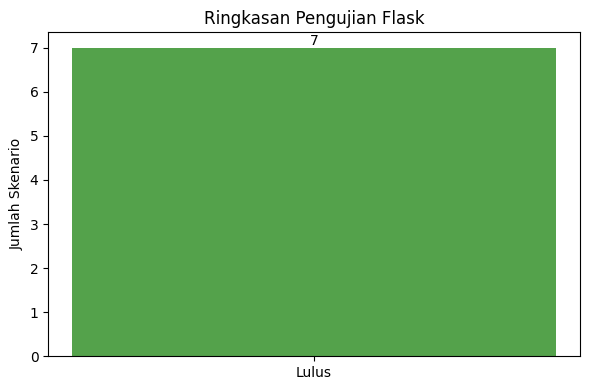

In [15]:
test_results = pd.DataFrame([
    {
        "Skenario": "GET informasi API",
        "Status Harapan": 200,
        "Status Aktual": home_response.status_code,
    },
    {
        "Skenario": "POST teks valid",
        "Status Harapan": 200,
        "Status Aktual": valid_response.status_code,
    },
    {
        "Skenario": "Input kosong",
        "Status Harapan": 400,
        "Status Aktual": empty_response.status_code,
    },
    {
        "Skenario": "Input hanya spasi",
        "Status Harapan": 400,
        "Status Aktual": whitespace_response.status_code,
    },
    {
        "Skenario": "Field text tidak ada",
        "Status Harapan": 400,
        "Status Aktual": missing_field_response.status_code,
    },
    {
        "Skenario": "Request bukan JSON",
        "Status Harapan": 400,
        "Status Aktual": non_json_response.status_code,
    },
    {
        "Skenario": "Angka dan tanda baca",
        "Status Harapan": 200,
        "Status Aktual": punctuation_response.status_code,
    },
])

test_results["Hasil"] = test_results.apply(
    lambda row: (
        "Lulus"
        if row["Status Harapan"] == row["Status Aktual"]
        else "Gagal"
    ),
    axis=1,
)

display(test_results)

summary = test_results["Hasil"].value_counts()

plt.figure(figsize=(6, 4))
colors = [
    "#54A24B" if label == "Lulus" else "#E45756"
    for label in summary.index
]

bars = plt.bar(summary.index, summary.values, color=colors)
plt.title("Ringkasan Pengujian Flask")
plt.ylabel("Jumlah Skenario")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 4.7 Pembahasan

Pengujian menunjukkan bahwa aplikasi mampu menyediakan informasi layanan, memproses teks valid, dan menolak input kosong. Respons JSON memuat hasil tiap tahap preprocessing serta bobot TF-IDF. Penggunaan test client sesuai untuk verifikasi fungsi Flask di Google Colab karena fokus pengujian berada pada routing, validasi, dan isi respons, bukan deployment.

Implementasi ini menggunakan resource bahasa Inggris. Untuk teks bahasa Indonesia, stopword dan stemmer perlu diganti dengan resource yang sesuai, misalnya Sastrawi, dan model Stanza bahasa Indonesia harus digunakan.


## BAB 5 — KESIMPULAN, KETERBATASAN, DAN SARAN

Bagian berikut disusun secara otomatis berdasarkan hasil pengujian yang dijalankan pada BAB 4.


In [8]:
# Data bersama dari hasil pengujian BAB 4
test_passed = all(passed)
processed = valid_response.get_json()
token_count = len(processed.get('tokens', []))
tfidf_count = len(processed.get('tfidf', {}))


### 5.1 Kesimpulan

Kesimpulan berikut dibuat otomatis berdasarkan hasil eksekusi pengujian.


In [9]:
if test_passed:
    conclusion_text = (
        f"Pipeline preprocessing dan REST API Flask berhasil diuji. Teks menghasilkan {token_count} token dan {tfidf_count} fitur TF-IDF. Seluruh pengujian endpoint dan validasi input berhasil."
    )
else:
    conclusion_text = (
        'Pipeline belum sepenuhnya berhasil karena terdapat pengujian yang gagal. Periksa kembali output setiap endpoint.'
    )
print('5.1 Kesimpulan')
print(conclusion_text)


5.1 Kesimpulan
Pipeline preprocessing dan REST API Flask berhasil diuji. Teks menghasilkan 5 token dan 4 fitur TF-IDF. Seluruh pengujian endpoint dan validasi input berhasil.


### 5.2 Keterbatasan

Keterbatasan disusun berdasarkan lingkungan dan data eksperimen.


In [10]:
limitations = [
    'Eksperimen menggunakan contoh teks berbahasa Inggris.',
    'TF-IDF dihitung pada satu dokumen sehingga belum menggambarkan variasi korpus.',
    'Pengujian dilakukan pada runtime Google Colab yang bersifat sementara.',
]
print('5.2 Keterbatasan')
for item in limitations:
    print('- ' + item)


5.2 Keterbatasan
- Eksperimen menggunakan contoh teks berbahasa Inggris.
- TF-IDF dihitung pada satu dokumen sehingga belum menggambarkan variasi korpus.
- Pengujian dilakukan pada runtime Google Colab yang bersifat sementara.


### 5.3 Saran

Saran berikut dihasilkan untuk pengembangan eksperimen selanjutnya.


In [11]:
recommendations = [
    'Gunakan dataset bahasa Indonesia dan resource linguistik yang sesuai.',
    'Tambahkan pengujian pada banyak dokumen serta metrik waktu dan akurasi.',
    'Tambahkan unit test dan deployment API apabila layanan perlu diakses publik.',
]
print('5.3 Saran')
for item in recommendations:
    print('- ' + item)


5.3 Saran
- Gunakan dataset bahasa Indonesia dan resource linguistik yang sesuai.
- Tambahkan pengujian pada banyak dokumen serta metrik waktu dan akurasi.
- Tambahkan unit test dan deployment API apabila layanan perlu diakses publik.


## REFERENSI

1. Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media. https://www.nltk.org/book/
2. Qi, P., Zhang, Y., Zhang, Y., Bolton, J., & Manning, C. D. (2020). Stanza: A Python Natural Language Processing Toolkit for Many Human Languages. *Proceedings of ACL 2020: System Demonstrations*, 101–108. https://doi.org/10.18653/v1/2020.acl-demos.14
3. Grinberg, M. (2018). *Flask Web Development: Developing Web Applications with Python* (2nd ed.). O'Reilly Media.
4. Ramos, J. (2003). Using TF-IDF to Determine Word Relevance in Document Queries. *Proceedings of the First Instructional Conference on Machine Learning*.
5. Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press. https://nlp.stanford.edu/IR-book/
6. Sastrawi Documentation. Indonesian stemming library for Python. https://github.com/har07/PySastrawi
